## KNN Classifier (n=1) Accuracy: 0.8227
## Gradient Boosting Classifier Accuracy: 0.9456

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]



print(f"\n{df['CAEC'].value_counts().to_string()}")
print(f"\n{df['CALC'].value_counts().to_string()}")
print(f"\n{df['MTRANS'].value_counts().to_string()}")


CAEC
Sometimes     1765
Frequently     242
Always          53
no              51

CALC
Sometimes     1401
no             639
Frequently      70
Always           1

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7


In [6]:
X['Gender'] = X['Gender'].map({"Female": 0, "Male": 1})
X['family_history_with_overweight'] = X['family_history_with_overweight'].map({"no": 0, "yes": 1})
X['FAVC'] = X['FAVC'].map({"no": 0, "yes": 1})
X['CAEC'] = X['CAEC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['SMOKE'] = X['SMOKE'].map({"no": 0, "yes": 1})
X['SCC'] = X['SCC'].map({"no": 0, "yes": 1})
X['CALC'] = X['CALC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['MTRANS'] = X['MTRANS'].map({"Automobile": 0, "Motorbike": 1, "Bike": 2, "Public_Transportation": 3, "Walking": 4})
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


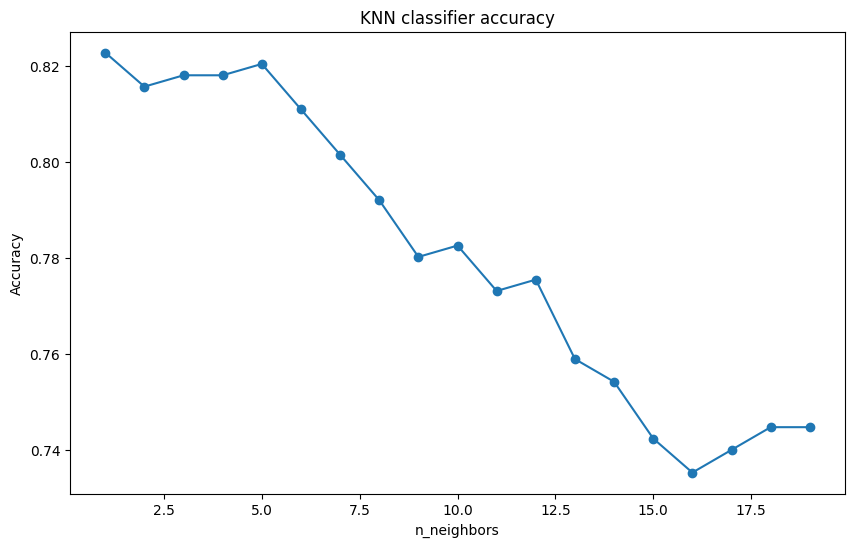

In [ ]:
accuracy_scores = []
for n in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), accuracy_scores, marker='o')
plt.title("KNN classifier accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.show()






In [33]:
# final knn----n=1
knn_final = KNeighborsClassifier(n_neighbors=1)
knn_final.fit(X_train_scaled, y_train)

print(f'Accuracy of KNN (n=1) on training set: {knn_final.score(X_train_scaled, y_train):.4f}')
print(f'Accuracy of KNN (n=1) on test set: {knn_final.score(X_test_scaled, y_test):.4f}\n')



Accuracy of KNN (n=1) on training set: 1.0000
Accuracy of KNN (n=1) on test set: 0.8227



In [32]:
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled, y_train)

print(f'Accuracy of Gradient Boosted DTs on training set: {gbc.score(X_train_scaled, y_train):.4f}')
print(f'Accuracy of Gradient Boosted DTs on test set: {gbc.score(X_test_scaled, y_test):.4f}\n')

Accuracy of Gradient Boosted DTs on training set: 1.0000
Accuracy of Gradient Boosted DTs on test set: 0.9456

